In [16]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'

cell_classifications = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:

from scipy.ndimage import gaussian_filter
from sklearn.metrics import accuracy_score, precision_score, recall_score
import warnings

# ── Cache directory ───────────────────────────────────────────────────────
CACHE_DIR = '/Users/harryclark/Documents/spatial-manifolds/data/ta_xgboost_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

_CLF_COLS = ['mouse', 'day', 'gc_cluster_id', 'gc_shank', 'sc_x', 'sc_x_bin',
             'cov_shank', 'shank_dist', 'pR2', 'accuracy', 'precision', 'recall',
             'n_trials', 'n_ngs_cells', 'pR2_ta', 'pR2_nta',
             'accuracy_ta', 'precision_ta', 'recall_ta',
             'accuracy_nta', 'precision_nta', 'recall_nta']

def cache_path(mouse_id, day_id):
    return os.path.join(CACHE_DIR, f'M{mouse_id}_D{day_id:02d}_clf.pkl')


def _fmt_pR2(val):
    if val is not None and not (val is np.nan or (isinstance(val, float) and np.isnan(val))):
        return f"{val:.3f}"
    return "NaN"

def _epoch_metrics(y_true, y_pred, epoch_label):
    """Compute accuracy/precision/recall for trials belonging to one epoch label (0 or 1)."""
    mask = (y_true == epoch_label)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    yt = y_true[mask]
    yp = y_pred[mask]
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    return acc, prec, rec

# ── Helper: derive per-trial TA labels from a linearised tuning curve ────
# tc       : 1-D or 2-D array (2-D is ravelled automatically)
# n_trials : expected output length; NaN array of this length returned on failure
def ta_labels_from_tc(tc, n_trials, peak_indices=[12, 28, 44, 60, 76], sigma=2.5):
    _nan = np.full(n_trials, np.nan)
    try:
        tc = np.nan_to_num(np.asarray(tc).ravel())
        tcs_for_spec = {0: tc, 1000: tc}
        results      = spectral_analysis(tcs_for_spec, tl, bs=bs)
        spectrograms = results[3]
        S            = spectrograms.mean(0)
        max_peaks    = np.argmax(S, axis=0)
        labels       = np.isin(max_peaks, peak_indices).astype(int)
        print(f"    [ta_labels_from_tc] labels: shape={labels.shape}, unique={np.unique(labels)}, n_peaks={labels.sum()}, n_trials={n_trials}")
        tc_smooth    = gaussian_filter(tc.astype(np.float64), sigma=sigma)
        per_trial    = get_kmeans_spatial_labels(tc_smooth, labels, bs=bs, tl=tl)
        if per_trial is None:
            print(f"    [ta_labels_from_tc] per_trial=None → returning NaN array")
            return _nan
        per_trial = np.asarray(per_trial, dtype=float)
        print(f"    [ta_labels_from_tc] per_trial: shape={per_trial.shape}, unique={np.unique(per_trial[~np.isnan(per_trial)])}")
        return per_trial
    except Exception as e:
        print(f"    [ta_labels_from_tc] {e}")
        return _nan


# ── Helper: reconstruct trial×position rate map from time-series ─────────
def reconstruct_tc(y_time, trial_number_in_time, pos_in_time, n_bins):
    trials    = np.unique(trial_number_in_time.astype(int))
    tc_hat    = np.full((len(trials), n_bins), np.nan)
    bin_edges = np.linspace(0, tl, n_bins + 1)
    for t_i, trial in enumerate(trials):
        mask  = trial_number_in_time.astype(int) == trial
        pos_t = pos_in_time[mask]
        y_t   = y_time[mask]
        for b in range(n_bins):
            b_mask = (pos_t >= bin_edges[b]) & (pos_t < bin_edges[b + 1])
            if np.sum(b_mask) > 0:
                tc_hat[t_i, b] = y_t[b_mask].mean()
    return np.nan_to_num(tc_hat)


In [18]:

# ── Session / binning parameters ─────────────────────────────────────────
nfilters       = 5
history_length = 1000   # ms
n_bins         = int(tl / bs)   # position bins per trial (100 for tl=200, bs=2)

shanks      = [0, 1, 2, 3]
# Bins: '2800–3000', '3000–3200', …, '3800–4000'
sc_x_edges  = np.arange(2800, 4001, 200)
sc_x_labels = [f'{int(sc_x_edges[i])}–{int(sc_x_edges[i+1])}' for i in range(len(sc_x_edges) - 1)]

xgb_history = MLencoding(tunemodel='xgboost',
                         cov_history=True, spike_history=False,
                         window=time_bs, n_filters=nfilters,
                         max_time=history_length)

gc_sessions    = cell_classifications[cell_classifications['cell_type'] == 'GC'][['mouse', 'day']].drop_duplicates()
ngs_sessions   = cell_classifications[cell_classifications['cell_type'] == 'NG'][['mouse', 'day']].drop_duplicates()
valid_sessions = gc_sessions.merge(ngs_sessions, on=['mouse', 'day'])
expected_shanks = {0, 1, 2, 3}

all_session_dfs = []

for _, sess_row in valid_sessions.iterrows():
    mouse_id = int(sess_row['mouse'])
    day_id   = int(sess_row['day'])
    cp = cache_path(mouse_id, day_id)

    # ── Load from cache if available ─────────────────────────────────────
    if os.path.exists(cp):
        cached = pd.read_pickle(cp)
        print(f"[cache] M{mouse_id} D{day_id:02d}  ({len(cached)} rows)")
        all_session_dfs.append(cached)
        continue

    print(f"\n=== M{mouse_id} D{day_id:02d} ===")

    # ── Check NGS shank coverage before loading heavy data ────────────────
    sess_gcs = cell_classifications[
        (cell_classifications['mouse'] == mouse_id) &
        (cell_classifications['day']   == day_id) &
        (cell_classifications['cell_type'] == 'GC')
    ].copy()
    sess_ngs = cell_classifications[
        (cell_classifications['mouse'] == mouse_id) &
        (cell_classifications['day']   == day_id) &
        (cell_classifications['cell_type'] == 'NG')
    ].copy()

    sess_gcs['cluster_id'] = sess_gcs['cluster_id'].astype(int)
    sess_ngs['cluster_id'] = sess_ngs['cluster_id'].astype(int)
    sess_gcs = reconstruct_shank_id(sess_gcs, mouse_id, colname='probe_x')
    sess_ngs = reconstruct_shank_id(sess_ngs, mouse_id, colname='probe_x')

    ngs_shanks = set(sess_ngs['shank_id'].dropna().astype(int).unique())
    if ngs_shanks != expected_shanks:
        print(f"  NGS not on all shanks ({sorted(ngs_shanks)}) — skipping."); continue

    print(f"  GCs: {len(sess_gcs)}  NGS: {len(sess_ngs)}")

    # ── Load session data only after shank check passes ───────────────────
    try:
        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
            mouse_id, day_id,
            apply_zscore=False, apply_guassian_filter=False,
            source_path=source_path,
        )
    except Exception as e:
        print(f"[compute_vr_tcs] failed: {e}"); continue

    # ── Time-binned position / trial mapping ─────────────────────────────
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms').index[-1]
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')
    dt_in_time = np.array(
        beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
        - ((beh['trial_number'][0] - 1) * tl)
    )
    if np.any(np.isnan(dt_in_time)):
        dt_in_time = np.array(pd.Series(dt_in_time).ffill().bfill())
    pos_in_time   = dt_in_time % tl
    trial_in_time = (dt_in_time // tl) + beh['trial_number'][0]

    # Number of complete trials in this session
    n_trials_sess = int(last_ephys_bin // n_bins)

    # First trial number (for aligning trial_in_time → actual_labels index)
    first_trial = int(beh['trial_number'][0])

    # ── Pre-build per-shank NGS feature matrices ─────────────────────────
    ngs_X = {}
    for s in shanks:
        cids = sess_ngs[sess_ngs['shank_id'] == s]['cluster_id'].values.astype(int)
        cols = [np.array(tcs_time[c]) for c in cids if c in tcs_time]
        ngs_X[s] = np.column_stack(cols) if cols else None

    # ── Loop over GCs ─────────────────────────────────────────────────────
    sess_rows = []
    for _, gc_row in sess_gcs.iterrows():
        gc_cid   = int(gc_row['cluster_id'])
        gc_shank = int(gc_row['shank_id'])
        # SC_x is positive; take abs() to be safe
        sc_x_raw = abs(pd.to_numeric(gc_row.get('SC_x', np.nan), errors='coerce'))
        sc_x_bin = np.nan
        if not np.isnan(sc_x_raw):
            idx = int(np.digitize(sc_x_raw, sc_x_edges)) - 1
            if 0 <= idx <= len(sc_x_labels) - 1:
                sc_x_bin = sc_x_labels[idx]

        if gc_cid not in tcs or gc_cid not in tcs_time:
            continue

        actual_labels = ta_labels_from_tc(tcs[gc_cid], n_trials_sess)
        if np.all(np.isnan(actual_labels)) or len(np.unique(actual_labels[~np.isnan(actual_labels)])) < 2:
            continue
        if len(actual_labels) != n_trials_sess:
            print(f"  [warn] GC {gc_cid}: actual_labels length {len(actual_labels)} != n_trials_sess {n_trials_sess}")
            continue

        y_time = np.array(tcs_time[gc_cid])

        for cov_shank in shanks:
            X = ngs_X.get(cov_shank)
            if X is None:
                continue
            T     = min(len(y_time), X.shape[0])
            X_use = X[:T]
            y_use = y_time[:T]
            pos_t = pos_in_time[:T]
            tri_t = trial_in_time[:T]

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    Y_hat, pR2_cv = xgb_history.fit_cv(
                        X_use, y_use, verbose=0, continuous_folds=True)

                # ── pR2 split by TA / non-TA epochs ──────────────────────
                # Map each time bin → 0-indexed trial → actual_label
                t0idx       = tri_t.astype(int) - first_trial
                in_range    = (t0idx >= 0) & (t0idx < len(actual_labels))
                time_labels = np.full(len(tri_t), np.nan)
                time_labels[in_range] = actual_labels[t0idx[in_range]]

                ta_mask  = (time_labels == 1)
                nta_mask = (time_labels == 0)
                ynull     = float(np.mean(y_use))
                ynull_ta  = float(np.mean(y_use[ta_mask])) if ta_mask.sum() > 0 else ynull
                ynull_nta = float(np.mean(y_use[nta_mask])) if nta_mask.sum() > 0 else ynull

                pR2_ta   = float(poisson_pseudoR2(y_use[ta_mask],  Y_hat[ta_mask],  ynull_ta)) \
                           if ta_mask.sum() > 10 else np.nan
                pR2_nta  = float(poisson_pseudoR2(y_use[nta_mask], Y_hat[nta_mask], ynull_nta)) \
                           if nta_mask.sum() > 10 else np.nan
                pR2_all  = float(np.nanmean(pR2_cv))

                print(f"    GC {gc_cid} cov_shank {cov_shank}: "
                      f"pR2_all={_fmt_pR2(pR2_all)}  "
                      f"pR2_ta={_fmt_pR2(pR2_ta)}  "
                      f"pR2_nta={_fmt_pR2(pR2_nta)}  "
                      f"(n_ta={ta_mask.sum()}, n_nta={nta_mask.sum()})")

                tc_hat        = reconstruct_tc(Y_hat, tri_t, pos_t, n_bins)
                n_pred_trials = tc_hat.shape[0]
                pred_labels   = ta_labels_from_tc(tc_hat, n_pred_trials)
                if np.all(np.isnan(pred_labels)):
                    continue
                if len(pred_labels) != n_pred_trials:
                    print(f"    [warn] GC {gc_cid} cov_shank {cov_shank}: pred_labels length {len(pred_labels)} != n_pred_trials {n_pred_trials}")
                    continue

                # Use only trials where both labels are valid
                valid = ~np.isnan(actual_labels[:n_pred_trials]) & ~np.isnan(pred_labels)
                n = valid.sum()
                if n == 0:
                    continue
                y_true = actual_labels[:n_pred_trials][valid].astype(int)
                y_pred = pred_labels[valid].astype(int)
                if len(np.unique(y_true)) < 2:
                    continue

                # ── Per-epoch accuracy / precision / recall ───────────────
                # TA trials (y_true==1): how well are TA trials classified?
                # NTA trials (y_true==0): how well are NTA trials classified?
                acc_ta,  prec_ta,  rec_ta  = _epoch_metrics(y_true, y_pred, epoch_label=1)
                acc_nta, prec_nta, rec_nta = _epoch_metrics(y_true, y_pred, epoch_label=0)

                sess_rows.append(dict(
                    mouse=mouse_id, day=day_id,
                    gc_cluster_id=gc_cid,
                    gc_shank=gc_shank,
                    sc_x=sc_x_raw,
                    sc_x_bin=sc_x_bin,
                    cov_shank=cov_shank,
                    shank_dist=abs(gc_shank - cov_shank),
                    pR2=pR2_all,
                    accuracy=accuracy_score(y_true, y_pred),
                    precision=precision_score(y_true, y_pred, zero_division=0),
                    recall=recall_score(y_true, y_pred, zero_division=0),
                    n_trials=int(n),
                    n_ngs_cells=X_use.shape[1],
                    pR2_ta=pR2_ta,
                    pR2_nta=pR2_nta,
                    accuracy_ta=acc_ta,   precision_ta=prec_ta,   recall_ta=rec_ta,
                    accuracy_nta=acc_nta, precision_nta=prec_nta, recall_nta=rec_nta,
                ))
            except Exception as e:
                print(f"    [skip] GC {gc_cid} cov_shank {cov_shank}: {e}")

    sess_df = pd.DataFrame(sess_rows, columns=_CLF_COLS) if sess_rows else pd.DataFrame(columns=_CLF_COLS)
    if len(sess_df) > 0:
        sess_df.to_pickle(cp)
        print(f"  Cached {len(sess_df)} rows → {cp}")
        all_session_dfs.append(sess_df)
    else:
        print(f"  No results for M{mouse_id} D{day_id:02d} (cache not written)")

clf_df = (pd.concat(all_session_dfs, ignore_index=True)
          if all_session_dfs else pd.DataFrame(columns=_CLF_COLS))

# ── Post-load fix: ensure sc_x is positive and sc_x_bin is a string label ──
if len(clf_df) > 0:
    clf_df['sc_x'] = pd.to_numeric(clf_df['sc_x'], errors='coerce').abs()
    def _assign_sc_x_bin(sc_x_val):
        if pd.isna(sc_x_val):
            return np.nan
        idx = int(np.digitize(sc_x_val, sc_x_edges)) - 1
        if 0 <= idx <= len(sc_x_labels) - 1:
            return sc_x_labels[idx]
        return np.nan
    clf_df['sc_x_bin'] = clf_df['sc_x'].apply(_assign_sc_x_bin)
    n_fixed = clf_df['sc_x_bin'].notna().sum()
    print(f"  sc_x_bin assigned for {n_fixed}/{len(clf_df)} rows  "
          f"(bins present: {sorted(clf_df['sc_x_bin'].dropna().unique())})")

n_sess = clf_df[['mouse', 'day']].drop_duplicates().shape[0] if len(clf_df) > 0 else 0
print(f"\nDone. {len(clf_df)} rows  ({n_sess} sessions)")
clf_df.head()



=== M20 D14 ===
  GCs: 4  NGS: 109
    [ta_labels_from_tc] labels: shape=(105,), unique=[0 1], n_peaks=38, n_trials=224
    [ta_labels_from_tc] per_trial: shape=(224,), unique=[0. 1.]
    GC 34 cov_shank 0: pR2_all=-0.011  pR2_ta=-0.023  pR2_nta=-0.036  (n_ta=84155, n_nta=98948)
    [ta_labels_from_tc] labels: shape=(105,), unique=[0 1], n_peaks=21, n_trials=224
    [ta_labels_from_tc] per_trial: shape=(224,), unique=[0. 1.]
    GC 34 cov_shank 1: pR2_all=0.047  pR2_ta=0.027  pR2_nta=0.022  (n_ta=84155, n_nta=98948)
    [ta_labels_from_tc] labels: shape=(105,), unique=[0 1], n_peaks=37, n_trials=224
    [ta_labels_from_tc] per_trial: shape=(224,), unique=[0. 1.]
    GC 34 cov_shank 2: pR2_all=0.052  pR2_ta=0.026  pR2_nta=0.029  (n_ta=84155, n_nta=98948)
    [ta_labels_from_tc] labels: shape=(105,), unique=[0 1], n_peaks=100, n_trials=224
    [ta_labels_from_tc] per_trial: shape=(224,), unique=[0. 1.]
    GC 34 cov_shank 3: pR2_all=-0.003  pR2_ta=-0.006  pR2_nta=-0.017  (n_ta=84155, n_

,mouse,day,gc_cluster_id,gc_shank,sc_x,sc_x_bin,cov_shank,shank_dist,pR2,accuracy,...,n_trials,n_ngs_cells,pR2_ta,pR2_nta,accuracy_ta,precision_ta,recall_ta,accuracy_nta,precision_nta,recall_nta
0,20,14,34,0,3150.0,3000–3200,0,0,-0.011465,0.651786,...,224,2,-0.023038,-0.035527,0.263158,1.0,0.263158,0.851351,0.0,0.0
1,20,14,34,0,3150.0,3000–3200,1,1,0.046603,0.464286,...,224,32,0.027241,0.021652,0.289474,1.0,0.289474,0.554054,0.0,0.0
2,20,14,34,0,3150.0,3000–3200,2,2,0.051765,0.383929,...,224,54,0.025947,0.028691,1.000000,1.0,1.000000,0.067568,0.0,0.0
3,20,14,34,0,3150.0,3000–3200,3,3,-0.003173,0.598214,...,224,21,-0.006260,-0.017476,0.157895,1.0,0.157895,0.824324,0.0,0.0
4,20,14,103,1,3330.0,3200–3400,0,1,-0.000081,0.428571,...,224,2,0.001578,-0.002858,0.090909,1.0,0.090909,0.913043,0.0,0.0


In [19]:

# ── Save ──────────────────────────────────────────────────────────────────
save_path = '/Users/harryclark/Documents/spatial-manifolds/data/ta_xgboost_shank_clf.csv'
clf_df.to_csv(save_path, index=False)
print(f"Saved {len(clf_df)} rows → {save_path}")


Saved 872 rows → /Users/harryclark/Documents/spatial-manifolds/data/ta_xgboost_shank_clf.csv


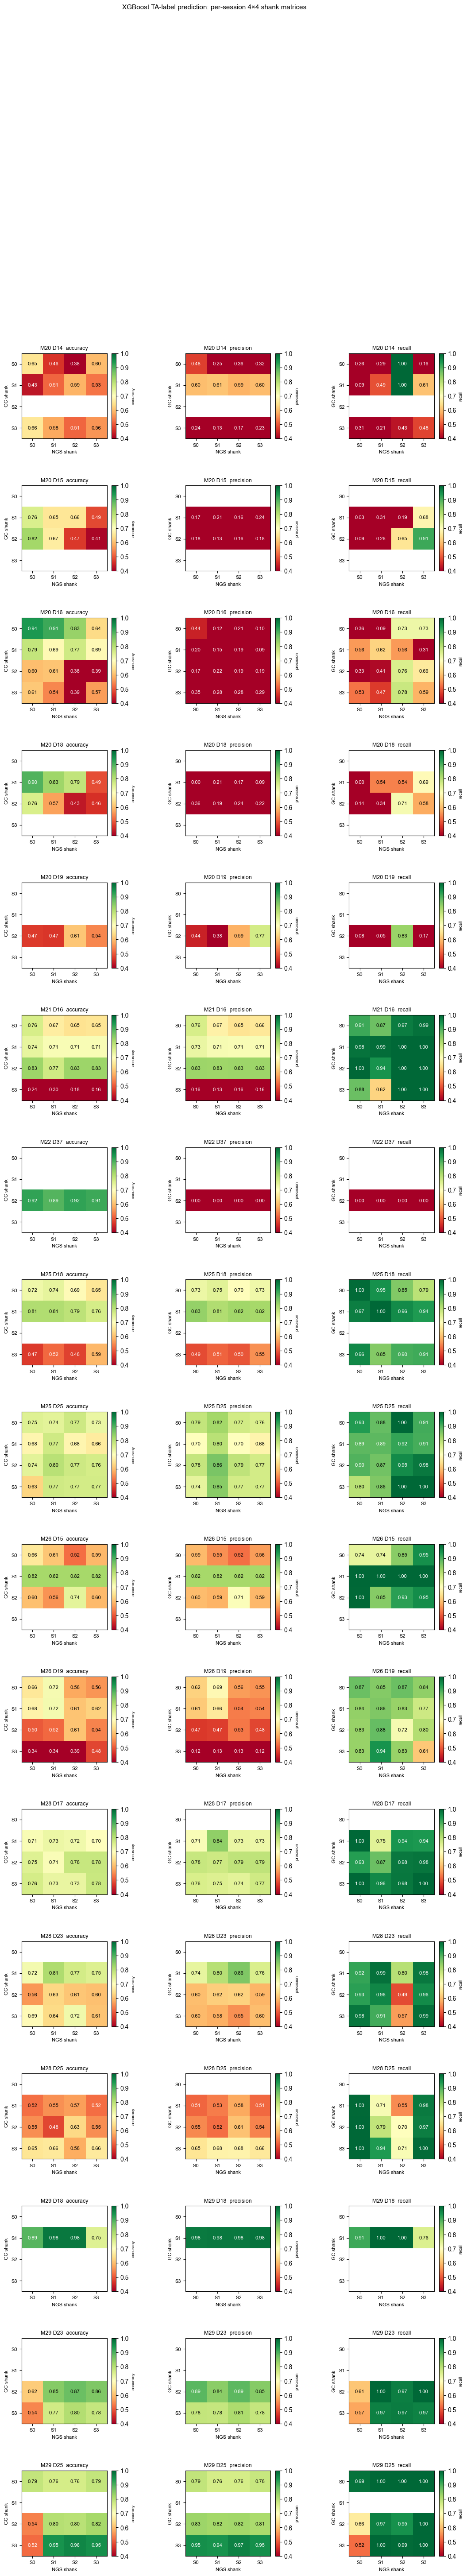

Saved ta_xgboost_shank_matrices.pdf


In [20]:

# ── Per-session 4×4 accuracy matrices  (rows=GC shank, cols=NGS shank) ───
import matplotlib.pyplot as plt
import numpy as np

valid_sess_list = (
    clf_df[['mouse','day']].drop_duplicates().sort_values(['mouse','day']).values
)
n_sess  = len(valid_sess_list)
shanks  = [0, 1, 2, 3]
metrics = ['accuracy', 'precision', 'recall']
cmap    = 'RdYlGn'
vmin, vmax = 0.4, 1.0

fig, axes = plt.subplots(n_sess, 3, figsize=(13, 3.8 * n_sess),
                         gridspec_kw={'wspace': 0.38, 'hspace': 0.55})
if n_sess == 1:
    axes = axes[np.newaxis, :]

tick_labels = [f'S{s}' for s in shanks]

for row_i, (mouse_id, day_id) in enumerate(valid_sess_list):
    sess = clf_df[(clf_df['mouse'] == mouse_id) & (clf_df['day'] == day_id)]

    for col_i, metric in enumerate(metrics):
        mat = np.full((4, 4), np.nan)
        for i, gc_s in enumerate(shanks):
            for j, cov_s in enumerate(shanks):
                vals = sess[(sess['gc_shank'] == gc_s) &
                            (sess['cov_shank'] == cov_s)][metric].dropna()
                if len(vals):
                    mat[i, j] = vals.mean()

        ax = axes[row_i, col_i]
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect='equal', interpolation='nearest')
        for i in range(4):
            for j in range(4):
                if not np.isnan(mat[i, j]):
                    txt_color = 'k' if 0.52 < mat[i, j] < 0.88 else 'w'
                    ax.text(j, i, f'{mat[i,j]:.2f}',
                            ha='center', va='center', fontsize=8, color=txt_color)
        ax.set_xticks(range(4)); ax.set_xticklabels(tick_labels, fontsize=8)
        ax.set_yticks(range(4)); ax.set_yticklabels(tick_labels, fontsize=8)
        ax.set_xlabel('NGS shank', fontsize=8)
        ax.set_ylabel('GC shank', fontsize=8)
        ax.set_title(f'M{int(mouse_id)} D{int(day_id)}  {metric}', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(metric, fontsize=7)

plt.suptitle('XGBoost TA-label prediction: per-session 4×4 shank matrices',
             fontsize=11, y=1.002)
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'ta_xgboost_shank_matrices.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ta_xgboost_shank_matrices.pdf")


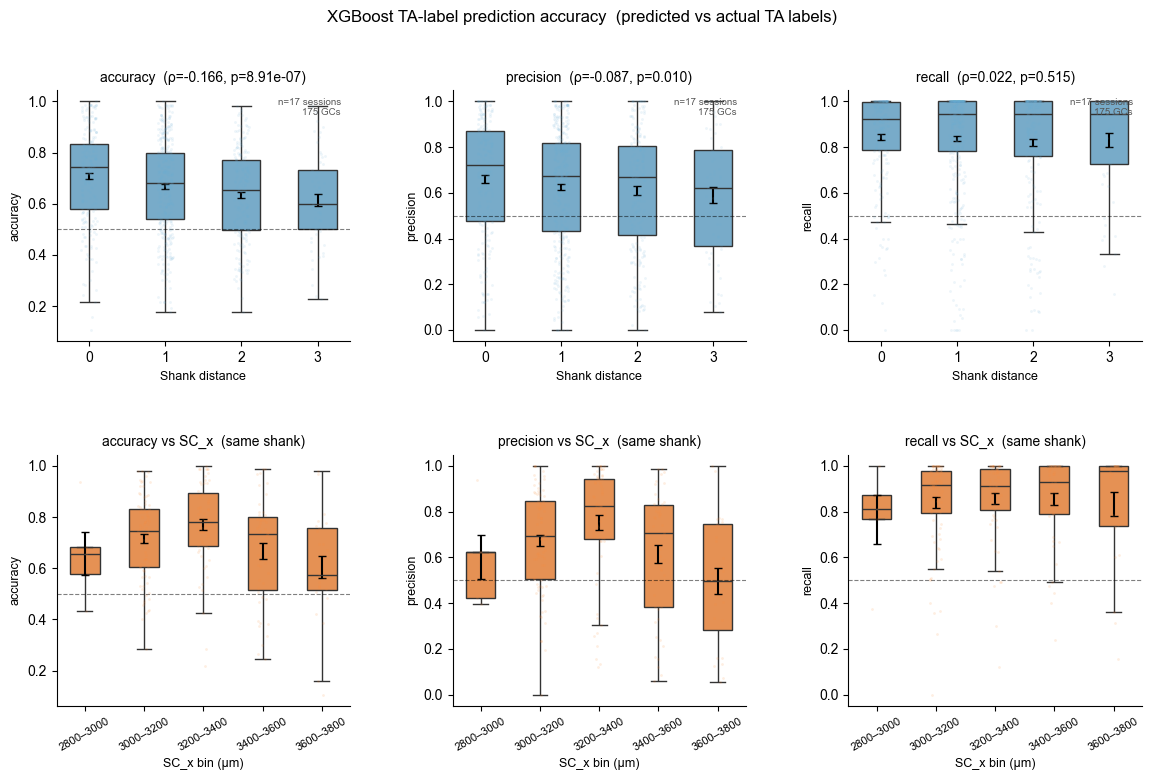

Saved ta_xgboost_clf_summary.pdf


In [21]:

# ── Population summary: accuracy / precision / recall vs shank dist and SC_x bin ──
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

metrics     = ['accuracy', 'precision', 'recall']
dist_order  = sorted(clf_df['shank_dist'].unique())
sc_x_order  = [b for b in sc_x_labels if b in clf_df['sc_x_bin'].unique()]

fig, axes = plt.subplots(2, 3, figsize=(14, 8),
                         gridspec_kw={'hspace': 0.45, 'wspace': 0.35})

# ── Top row: metric vs shank distance ────────────────────────────────────
for col, metric in enumerate(metrics):
    ax = axes[0, col]
    sns.boxplot(data=clf_df, x='shank_dist', y=metric,
                order=dist_order, color='#6baed6',
                width=0.5, fliersize=0, linecolor='#333333', ax=ax)
    sns.stripplot(data=clf_df, x='shank_dist', y=metric,
                  order=dist_order, color='#6baed6',
                  alpha=0.12, jitter=True, size=2, ax=ax)
    for i, d in enumerate(dist_order):
        v = clf_df.loc[clf_df['shank_dist'] == d, metric].dropna()
        if len(v):
            ax.errorbar(i, v.mean(), yerr=v.sem(),
                        fmt='none', color='k', capsize=3, linewidth=1.5)
    r, p = spearmanr(clf_df['shank_dist'], clf_df[metric])
    p_str = f'{p:.2e}' if p < 0.001 else f'{p:.3f}'
    ax.set_title(f'{metric}  (ρ={r:.3f}, p={p_str})', fontsize=10)
    ax.set_xlabel('Shank distance', fontsize=9)
    ax.set_ylabel(metric, fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    n_sess = clf_df[['mouse', 'day']].drop_duplicates().shape[0]
    n_gc   = clf_df['gc_cluster_id'].nunique()
    ax.text(0.97, 0.97, f'n={n_sess} sessions\n{n_gc} GCs',
            transform=ax.transAxes, fontsize=7, ha='right', va='top', color='#555555')
    ax.axhline(0.5, color='k', lw=0.8, ls='--', alpha=0.5, label='chance')

# ── Bottom row: metric vs SC_x bin ───────────────────────────────────────
# Use same-shank pairs (shank_dist == 0) for the SC_x comparison
same = clf_df[clf_df['shank_dist'] == 0]

for col, metric in enumerate(metrics):
    ax = axes[1, col]
    sc_x_present = [b for b in sc_x_order if b in same['sc_x_bin'].unique()]
    sns.boxplot(data=same, x='sc_x_bin', y=metric,
                order=sc_x_present, color='#fd8d3c',
                width=0.5, fliersize=0, linecolor='#333333', ax=ax)
    sns.stripplot(data=same, x='sc_x_bin', y=metric,
                  order=sc_x_present, color='#fd8d3c',
                  alpha=0.15, jitter=True, size=2, ax=ax)
    for i, b in enumerate(sc_x_present):
        v = same.loc[same['sc_x_bin'] == b, metric].dropna()
        if len(v):
            ax.errorbar(i, v.mean(), yerr=v.sem(),
                        fmt='none', color='k', capsize=3, linewidth=1.5)
    ax.set_title(f'{metric} vs SC_x  (same shank)', fontsize=10)
    ax.set_xlabel('SC_x bin (µm)', fontsize=9)
    ax.set_ylabel(metric, fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.axhline(0.5, color='k', lw=0.8, ls='--', alpha=0.5)

fig.suptitle('XGBoost TA-label prediction accuracy  (predicted vs actual TA labels)',
             fontsize=12)
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'ta_xgboost_clf_summary.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved ta_xgboost_clf_summary.pdf")


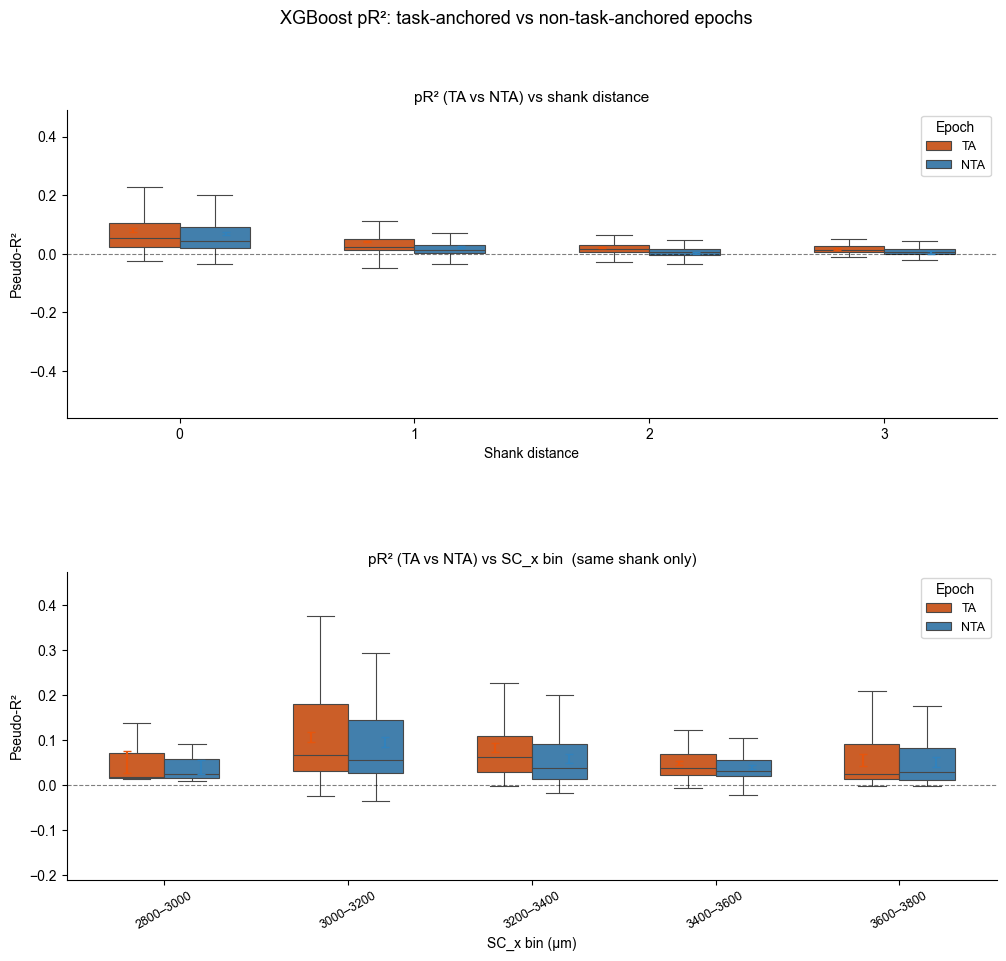

Saved ta_xgboost_pR2_ta_nta.pdf


In [22]:

# ── pR2 (TA vs NTA) vs shank distance and SC_x bin ───────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

palette_epoch = {'TA': '#e6550d', 'NTA': '#3182bd'}

# Melt pR2_ta / pR2_nta into long form
# value_name must not clash with existing clf_df columns (which include 'pR2')
pr2_long = pd.melt(
    clf_df,
    id_vars=['mouse', 'day', 'gc_cluster_id', 'gc_shank', 'sc_x_bin', 'shank_dist'],
    value_vars=['pR2_ta', 'pR2_nta'],
    var_name='epoch', value_name='pR2_val',
).dropna(subset=['pR2_val'])
pr2_long['epoch'] = pr2_long['epoch'].map({'pR2_ta': 'TA', 'pR2_nta': 'NTA'})

dist_order   = sorted(clf_df['shank_dist'].unique())
sc_x_order   = [b for b in sc_x_labels if b in clf_df['sc_x_bin'].unique()]

fig, axes = plt.subplots(2, 1, figsize=(12, 10),
                         gridspec_kw={'hspace': 0.5})

# ── Top: pR2 vs shank distance ────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=pr2_long, x='shank_dist', y='pR2_val', hue='epoch',
    order=dist_order, hue_order=['TA', 'NTA'],
    palette=palette_epoch,
    width=0.6, fliersize=0, linewidth=0.8, ax=ax,
)
for ei, epoch in enumerate(['TA', 'NTA']):
    sub = pr2_long[pr2_long['epoch'] == epoch]
    offsets = [-0.2, 0.2]
    for xi, d in enumerate(dist_order):
        v = sub.loc[sub['shank_dist'] == d, 'pR2_val'].dropna()
        if len(v):
            ax.errorbar(xi + offsets[ei], v.mean(), yerr=v.sem(),
                        fmt='none', color=palette_epoch[epoch],
                        capsize=3, linewidth=1.5, zorder=5)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Shank distance', fontsize=10)
ax.set_ylabel('Pseudo-R²', fontsize=10)
ax.set_title('pR² (TA vs NTA) vs shank distance', fontsize=11)
ax.legend(title='Epoch', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Bottom: pR2 vs SC_x bin (same shank only) ────────────────────────────
ax = axes[1]
same_pr2 = pr2_long[pr2_long['shank_dist'] == 0]
sc_x_present = [b for b in sc_x_order if b in same_pr2['sc_x_bin'].unique()]

sns.boxplot(
    data=same_pr2, x='sc_x_bin', y='pR2_val', hue='epoch',
    order=sc_x_present, hue_order=['TA', 'NTA'],
    palette=palette_epoch,
    width=0.6, fliersize=0, linewidth=0.8, ax=ax,
)
for ei, epoch in enumerate(['TA', 'NTA']):
    sub = same_pr2[same_pr2['epoch'] == epoch]
    offsets = [-0.2, 0.2]
    for xi, b in enumerate(sc_x_present):
        v = sub.loc[sub['sc_x_bin'] == b, 'pR2_val'].dropna()
        if len(v):
            ax.errorbar(xi + offsets[ei], v.mean(), yerr=v.sem(),
                        fmt='none', color=palette_epoch[epoch],
                        capsize=3, linewidth=1.5, zorder=5)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('SC_x bin (µm)', fontsize=10)
ax.set_ylabel('Pseudo-R²', fontsize=10)
ax.set_title('pR² (TA vs NTA) vs SC_x bin  (same shank only)', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.legend(title='Epoch', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('XGBoost pR²: task-anchored vs non-task-anchored epochs', fontsize=13)
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'ta_xgboost_pR2_ta_nta.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved ta_xgboost_pR2_ta_nta.pdf")


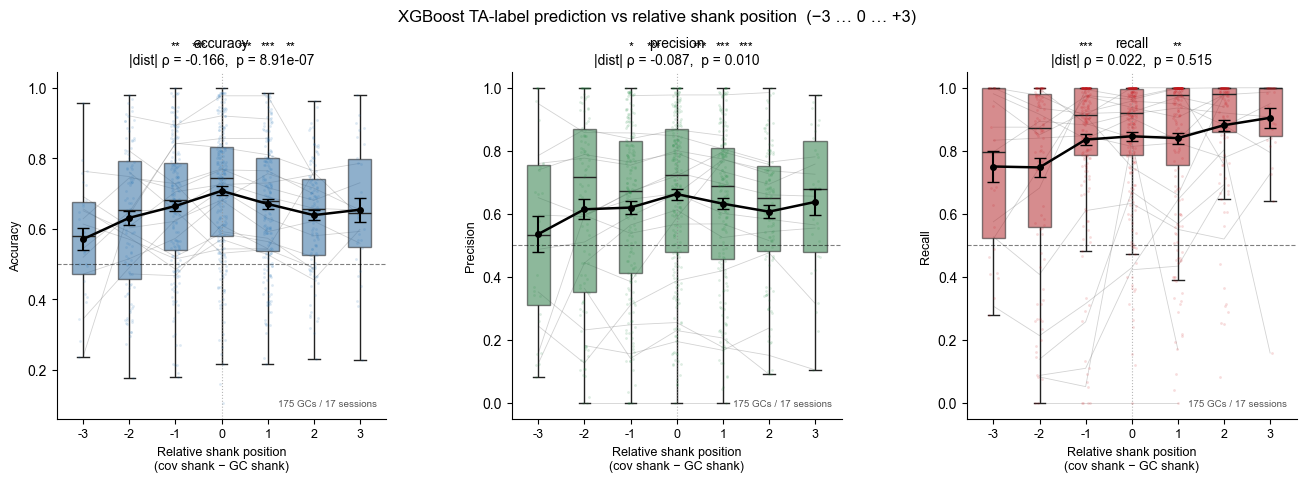

Saved ta_xgboost_shank_dist_metrics.pdf


: 

In [ ]:

# ── Shank-distance plot: accuracy / precision / recall vs relative shank position ──
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, wilcoxon

metrics      = ['accuracy', 'precision', 'recall']
palette      = {'accuracy': '#2171b5', 'precision': '#238b45', 'recall': '#cb181d'}

# Signed relative shank position: cov_shank − gc_shank  (−3 … 0 … +3)
plot_df = clf_df.copy()
plot_df['signed_dist'] = plot_df['cov_shank'].astype(int) - plot_df['gc_shank'].astype(int)
dist_order = list(range(-3, 4))   # −3, −2, −1, 0, 1, 2, 3
n_dist     = len(dist_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5),
                         gridspec_kw={'wspace': 0.38})

for ax, metric in zip(axes, metrics):
    color = palette[metric]

    # ── Boxplot + strip ───────────────────────────────────────────────────
    sns.boxplot(
        data=plot_df, x='signed_dist', y=metric,
        order=dist_order, color=color,
        width=0.5, fliersize=0, linecolor='#222222',
        boxprops=dict(alpha=0.55), ax=ax,
    )
    sns.stripplot(
        data=plot_df, x='signed_dist', y=metric,
        order=dist_order, color=color,
        alpha=0.15, jitter=True, size=2, ax=ax,
    )

    # ── Mean ± SEM overlay ────────────────────────────────────────────────
    xs     = list(range(n_dist))
    means  = [plot_df.loc[plot_df['signed_dist'] == d, metric].dropna().mean() for d in dist_order]
    sems   = [plot_df.loc[plot_df['signed_dist'] == d, metric].dropna().sem()  for d in dist_order]
    ax.plot(xs, means, color='k', lw=1.8, zorder=5, marker='o', markersize=4)
    ax.errorbar(xs, means, yerr=sems, fmt='none', color='k',
                capsize=4, linewidth=1.5, zorder=6)

    # ── Spearman rho (using absolute distance to capture the U-shape) ─────
    r, p = spearmanr(plot_df['signed_dist'].abs(), plot_df[metric].values)
    p_str = f'{p:.2e}' if p < 0.001 else f'{p:.3f}'
    ax.set_title(f'{metric}\n|dist| ρ = {r:.3f},  p = {p_str}', fontsize=10)

    # ── Wilcoxon significance vs dist = 0 (per-GC means) ─────────────────
    d0_vals = (
        plot_df[plot_df['signed_dist'] == 0]
        .groupby(['mouse', 'day', 'gc_cluster_id'])[metric].mean()
    )
    y_top    = ax.get_ylim()[1]
    bar_step = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.06
    for xi, d in enumerate(dist_order):
        if d == 0:
            continue
        d_vals = (
            plot_df[plot_df['signed_dist'] == d]
            .groupby(['mouse', 'day', 'gc_cluster_id'])[metric].mean()
        )
        common = d0_vals.index.intersection(d_vals.index)
        if len(common) < 5:
            continue
        _, pw = wilcoxon(d0_vals[common], d_vals[common])
        if pw < 0.05:
            sig   = '***' if pw < 0.001 else ('**' if pw < 0.01 else '*')
            zero_xi = dist_order.index(0)
            bar_y = y_top + bar_step * 0.8
            ax.annotate('', xy=(xi, bar_y), xytext=(zero_xi, bar_y),
                        arrowprops=dict(arrowstyle='-', color='k', lw=1))
            ax.text((xi + zero_xi) / 2, bar_y + bar_step * 0.1, sig,
                    ha='center', va='bottom', fontsize=9, color='k')

    ax.axhline(0.5, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.axvline(dist_order.index(0), color='#888888', lw=0.8, ls=':', alpha=0.6)
    ax.set_xlabel('Relative shank position\n(cov shank − GC shank)', fontsize=9)
    ax.set_ylabel(metric.capitalize(), fontsize=9)
    ax.set_xticks(xs)
    ax.set_xticklabels([str(d) for d in dist_order], fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Per-session mean trend lines (thin, grey) ─────────────────────────
    for (mid, did), sg in plot_df.groupby(['mouse', 'day']):
        sess_means = [sg[sg['signed_dist'] == d][metric].mean() for d in dist_order]
        ax.plot(xs, sess_means, color='grey', lw=0.6, alpha=0.35, zorder=1)

    n_gc_v   = plot_df['gc_cluster_id'].nunique()
    n_sess_v = plot_df[['mouse', 'day']].drop_duplicates().shape[0]
    ax.text(0.97, 0.03, f'{n_gc_v} GCs / {n_sess_v} sessions',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='#555555')

fig.suptitle(
    'XGBoost TA-label prediction vs relative shank position  (−3 … 0 … +3)',
    fontsize=12, y=1.02,
)
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'ta_xgboost_shank_dist_metrics.pdf',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved ta_xgboost_shank_dist_metrics.pdf")
